# Student Performance Dataset Project

## Project Overview
This project uses the **Student Performance Dataset** from the UCI Machine Learning Repository. The dataset contains information collected from Portuguese secondary school students, including demographics, study habits, family background, social behaviors, and academic performance.

The main goal of this project is to analyze factors that may affect student academic success and build machine learning models to predict student performance.

## Dataset Source
UCI Machine Learning Repository:
https://archive.ics.uci.edu/dataset/320/student+performance

## Possible Research Questions
- Does study time improve student grades?
- Do absences negatively affect academic performance?
- How does family support relate to grades?
- Can we predict final grades using student lifestyle and academic information?

## Project Goals
1. Download and load the dataset
2. Explore and clean the data
3. Visualize important relationships
4. Build predictive models
5. Evaluate model performance


# Student Performance Dataset Project

## Project Overview
This project uses the **Student Performance Dataset** from the UCI Machine Learning Repository. The dataset contains information collected from Portuguese secondary school students, including demographics, study habits, family background, social behaviors, and academic performance.

The main goal of this project is to analyze factors that may affect student academic success and build machine learning models to predict student performance.

## Dataset Source
UCI Machine Learning Repository:
https://archive.ics.uci.edu/dataset/320/student+performance

## Project Goals
1. Download and load the dataset
2. Explore and clean the data
3. Visualize important relationships
4. Build predictive models
5. Evaluate model performance


In [29]:
# Install the package if needed:
# !pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Fetch the Student Performance dataset
student_performance = fetch_ucirepo(id=320)

# Extract features and targets
X = student_performance.data.features
y = student_performance.data.targets

# Combine into one dataframe
df = pd.concat([X, y], axis=1)

# Save a local CSV copy
df.to_csv("student_performance.csv", index=False)

print("Dataset downloaded successfully!")
print("Dataset shape:", df.shape)


Dataset downloaded successfully!
Dataset shape: (649, 33)


In [30]:
# Preview the dataset

display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13



Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [31]:
# Dataset information

df.info()

print("\nMissing Values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [32]:
# Targets
grades = student_performance.data.targets

# Features
features = student_performance.data.features

Text(0.5, 0, 'Grades')

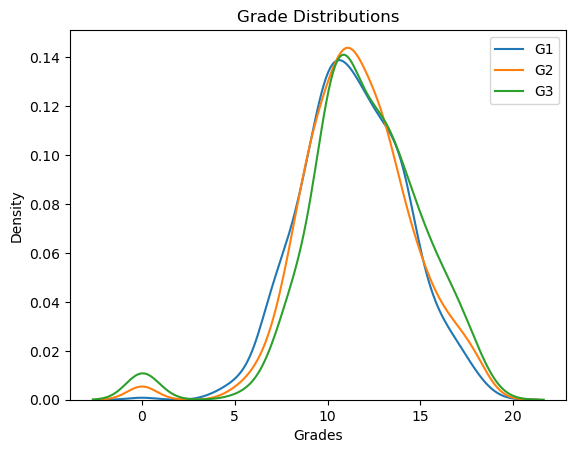

In [34]:
for col in grades.columns:
    sns.kdeplot(data=grades, x=col, label=col)


plt.legend()
plt.title("Grade Distributions")
plt.xlabel('Grades')

/var/folders/r2/plrh1xlx4_b6wmq2hw3_92dw0000gn/T/ipykernel_35965/3225566461.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['traveltime_label'] = features['traveltime'].map(traveltime_map)


<Axes: xlabel='reason', ylabel='G3'>

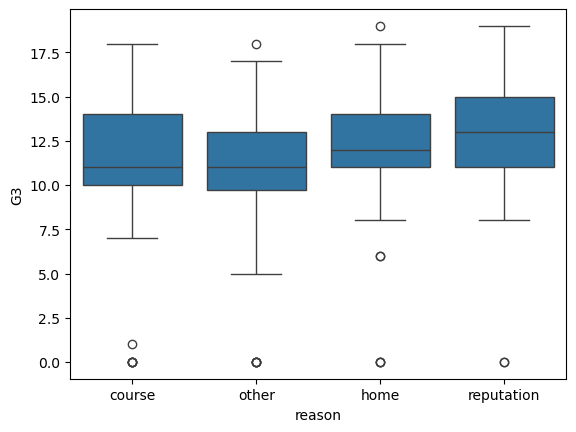

In [44]:
traveltime_map = {
    1: "<15 min",
    2: "15-30 min",
    3: "30-60 min",
    4: ">1 hour"
}

features['traveltime_label'] = features['traveltime'].map(traveltime_map)

combined = combined = pd.concat([features, grades], axis=1)
sns.boxplot(x='reason', y='G3', data=combined)